In [3]:
# -*- coding: utf-8 -*-
from __future__ import division
#import matplotlib
from pylab import *
# from scipy import *
import sys
import os
import glob
import random
# import scipy.optimize as optimize
# from scipy.optimize import curve_fit
import collections
import math
from numpy import linalg as LA
import torch
from tqdm import tqdm

4.809912294277037


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 82.05it/s]


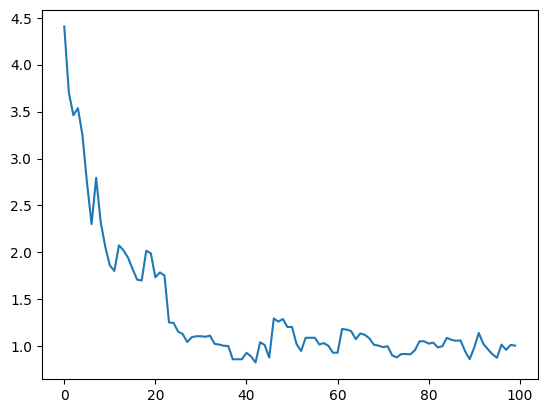

In [ ]:
K=float(5)

N=20	#100

# this for Rate 10 (reviewer question)
#f='Avalanche500stepsRate10_K='+str(float(K))+'_E='+str(float(factor_excitation))+'_I='+str(float(factor_inhibition))+'_P='+str(float(factor_neuronexc))+'_N='+str(N)+'_Runs='+str(n_runs)+'.dat'
#f2='TimeSeries500stepsRate10_K='+str(float(K))+'_E='+str(float(factor_excitation))+'_I='+str(float(factor_inhibition))+'_P='+str(float(factor_neuronexc))+'_N='+str(N)+'_Runs='+str(n_runs)+'.dat'

f='Bornholdt_Avalanche500steps_K='+str(float(K))+'_N='+str(N)+'.dat'

f2='Bornholdt_TimeSeries500steps_K='+str(float(K))+'_N='+str(N)+'.dat'


avalanche_vector=[]
ACT=[]

neuron_v=zeros((N))
neuron_v_new=zeros((N))
neuron_history=zeros((N))
weights=np.random.uniform(0,1, size=(N,N))
fill_diagonal(weights, 0)

ind=np.random.choice(range(N), int(N*0.2), replace=False)
weights[:,ind]=weights[:,ind]*-1

sum_weights=sum(weights)
weights=weights/sum_weights*N*K


# w, v = LA.eig(weights)
w = LA.eigvals(weights)
print(max(abs(w)))
#plot(1,1)
#show()

fire_data = []
 

Lamb_dyn=[]
for born in tqdm(range(100)): #1000
	neuron_history_older = zeros((N))
	neuron_history=zeros((N))

	for run in range(10):
		### start avalanche
		neuron_v=zeros((N))
		neuron_v[random.randint(0,N-1)]=1 	# background activity original, without Rate in filename
		t=0
		while sum(neuron_v)>0 and t<50:
			
			for i in range(N):
				
				prob_spiking=dot(weights[i,:], neuron_v)
				### Shew 2015
				#prob_spiking=0
				#for j in range(N):
				#	if i!=j:
				#		prob_spiking=prob_spiking + (weights[i,j]*neuron_v[j])
				if prob_spiking>=1.0:
					# print("this line runs")
					neuron_v_new[i]=1
					neuron_history[i]=1
				if prob_spiking>random.uniform(0,1) and prob_spiking<1:
					# print("or this")
					neuron_v_new[i]=1
					neuron_history[i]=1
				
				# print(neuron_v_new)
				# ACT.append(sum(neuron_v))
				fire_data.append(neuron_v_new.copy())
			
			neuron_v[:]=neuron_v_new[:]
			neuron_v_new[:]=0
			#neuron_v[random.randint(0,N-1)]=1 	# background activity original, without Rate in filename
			t=t+1
	#plt.plot(ACT)
	#plt.show()
		
	for _ in range(20):
		rand_neuron=random.randint(0,N-1)
		rand_incoming=random.randint(0,N-1)
		while rand_neuron==rand_incoming:
			rand_incoming=random.randint(0,N-1)

		#-----------original weight update-----------------
		if neuron_history[rand_neuron]==0:
			#if weights[rand_neuron,rand_incoming]<=0.9:
				weights[rand_neuron,rand_incoming]=np.random.uniform(0,1) #weights[rand_neuron,rand_incoming]+0.1#
		if neuron_history[rand_neuron]==1:
				weights[rand_neuron,rand_incoming]=0 #weights[rand_neuron,rand_incoming]-0.1#
				if weights[rand_neuron,rand_incoming]<0:
					weights[rand_neuron,rand_incoming]=0
		
		# #------------paper weight update--------------------
		# if neuron_history[rand_neuron] == 1:
		# 	if np.random.uniform(0,1) > 0.5:
		# 		weights[rand_neuron, rand_incoming] = -1
		# 	else:
		# 		weights[rand_neuron, rand_incoming] = 1
		# else:
		# 	weights[rand_neuron, rand_incoming] = 1

		#--------------Hebbian-----------------------
		# if born != 0:
			

	# if born % 100 == 0:
	# 	# w, v = LA.eig(weights)
	w = LA.eigvals(weights)
	Lamb_dyn.append(max(abs(w)))

plt.plot(Lamb_dyn)
plt.show()

In [6]:
type(neuron_history)

numpy.ndarray

3.8164446830844607


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 11388.15it/s]


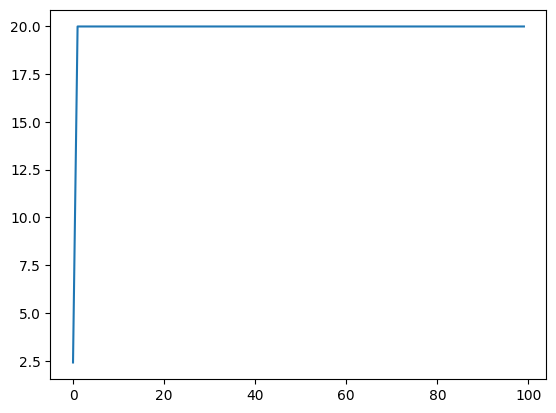

In [116]:
K=float(5)

N=20	#100

# this for Rate 10 (reviewer question)
#f='Avalanche500stepsRate10_K='+str(float(K))+'_E='+str(float(factor_excitation))+'_I='+str(float(factor_inhibition))+'_P='+str(float(factor_neuronexc))+'_N='+str(N)+'_Runs='+str(n_runs)+'.dat'
#f2='TimeSeries500stepsRate10_K='+str(float(K))+'_E='+str(float(factor_excitation))+'_I='+str(float(factor_inhibition))+'_P='+str(float(factor_neuronexc))+'_N='+str(N)+'_Runs='+str(n_runs)+'.dat'

f='Bornholdt_Avalanche500steps_K='+str(float(K))+'_N='+str(N)+'.dat'

f2='Bornholdt_TimeSeries500steps_K='+str(float(K))+'_N='+str(N)+'.dat'


avalanche_vector=[]
ACT=[]

neuron_v=zeros((N))
neuron_v_new=zeros((N))
neuron_history=zeros((N))
weights=np.random.uniform(0,1, size=(N,N))
fill_diagonal(weights, 0)

ind=np.random.choice(range(N), int(N*0.2), replace=False)
weights[:,ind]=weights[:,ind]*-1

sum_weights=sum(weights)
weights=weights/sum_weights*N*K


# w, v = LA.eig(weights)
w = LA.eigvals(weights)
print(max(abs(w)))
#plot(1,1)
#show()

fire_data = []
neuron_history_older = zeros((N))
neuron_history_older[random.randint(0,N-1)]=1
neuron_history=zeros((N))
Lamb_dyn=[]

for born in tqdm(range(10000)): #1000
  
    for i in range(N):
        
        prob_spiking=dot(weights[i,:], neuron_history_older)

        if prob_spiking>=1.0:
            neuron_history[i]=1
        if prob_spiking>random.uniform(0,1) and prob_spiking<1:
            neuron_history[i]=1
        
    fire_data.append(neuron_history.copy())
    
    # weight update
    activities = np.outer(neuron_history_older, neuron_history)
    weights += activities*0.6

    activities = (neuron_history_older[:, None] == 0) & (neuron_history[None, :] == 1)
    weights -= activities*0.6

    # rand_neuron=random.randint(0,N-1)
    # rand_incoming=random.randint(0,N-1)
    # while rand_neuron==rand_incoming:
    #     rand_incoming=random.randint(0,N-1)

    # #-----------original weight update-----------------
    # if neuron_history[rand_neuron]==0:
    #     #if weights[rand_neuron,rand_incoming]<=0.9:
    #         weights[rand_neuron,rand_incoming]=np.random.uniform(0,1) #weights[rand_neuron,rand_incoming]+0.1#
    # if neuron_history[rand_neuron]==1:
    #         weights[rand_neuron,rand_incoming]=0 #weights[rand_neuron,rand_incoming]-0.1#
    #         if weights[rand_neuron,rand_incoming]<0:
    #             weights[rand_neuron,rand_incoming]=0

    weights=weights/sum_weights*N*K

    # activities = (neuron_history_older[:, None] == 1) & (neuron_history[None, :] == 0)
    # weights -= activities*0.1


    neuron_history_older = neuron_history.copy()
    neuron_history[:] = 0


            

    if born % 100 == 0:
    # 	# w, v = LA.eig(weights)
        w = LA.eigvals(weights)
        Lamb_dyn.append(max(abs(w)))

plt.plot(Lamb_dyn)
# plt.savefig("hebbian_lambda.png", dpi=300)
plt.show()

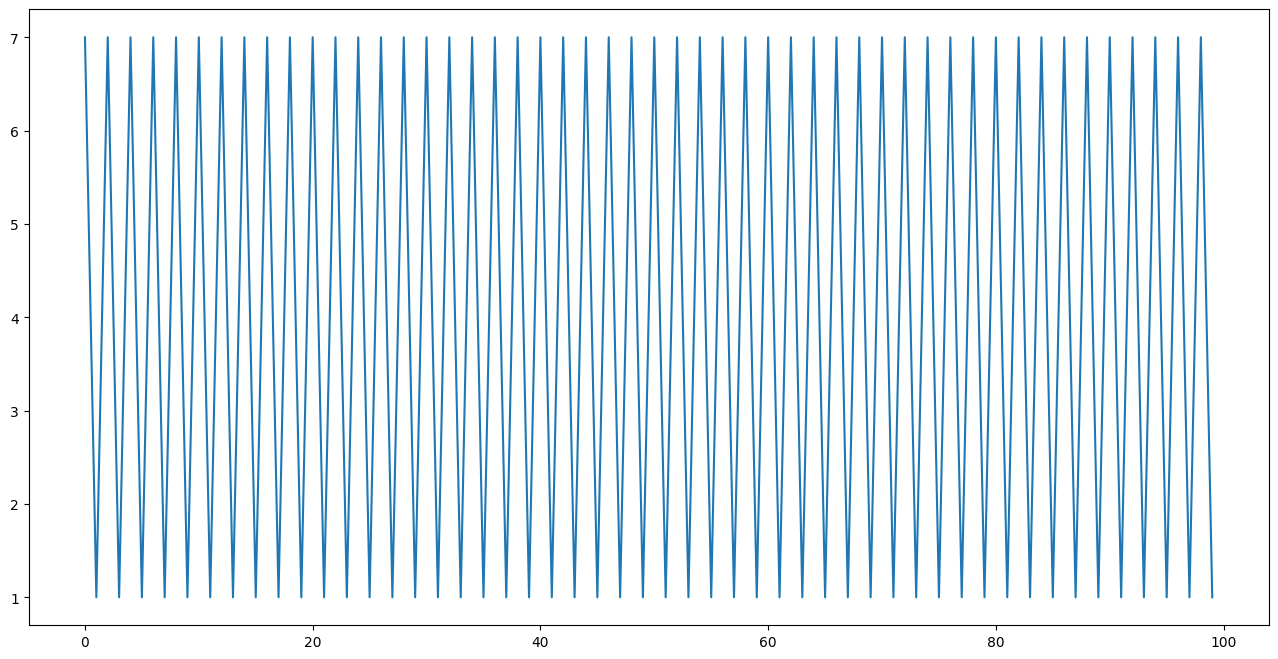

In [117]:
fire_data = np.array(fire_data)
plt.figure(figsize=(16,8))
plt.plot(fire_data[-100:].sum(axis=-1))
# plt.plot(fire_data[:100].sum(axis=-1))
# plt.plot(fire_data[:].sum(axis=-1))
# plt.savefig("activities.png", dpi=300)

In [ ]:
test = torch.matmul(torch.tensor(weights), torch.tensor(neuron_v))

In [ ]:
prob_spiking

2.0445025189250896

In [ ]:
v.shape

(200, 200)

In [ ]:
fire_data = np.array(fire_data)


In [ ]:
np.all(fire_data == 0)

False

In [ ]:
fire_data[250]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [118]:
test = fire_data[:1000]

In [119]:
import pickle
with open('fire_data_hebbian_v.pkl', 'wb') as f:
    pickle.dump(test, f)